# 多输入多通道

In [1]:
import torch
from d2l import torch as d2l

def corr2d_multi_in(X,K):
    """这是多通道输入计算互信息，下面使用的是之前实现的corr2d卷积运算（互信息运算）。
    多通道输入计算中，存在几个输入就存在几个卷积核，每个输入有对应的卷积和，这里使用python中自带的zip函数使得每个输入与其卷积核对应。
    
    :param X: 多通道输入，3维矩阵，中间的每一个矩阵都是一个输入
    :param K: 卷积核，维数和X一致
    :return: 返回计算的卷积矩阵，多通道输入计算返回只有1个矩阵
    """
    return sum(d2l.corr2d(x,k) for x,k in zip(X,K))

In [2]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

In [ ]:
def corr2d_multi_out(X,K):
    """多通道输出计算卷积。
    多通道输出计算中，卷积核维度多一维，由上面计算多通道输入的时候可以得到：输入和其对应的卷积核无论多少维，最后输出只有一个矩阵。
    如果想要得到多通道的输出，我们需要更多维数的卷积核，这样才可以实现多通道
    :param X: 上一层输出
    :param K: 多通道输出卷积核
    :return: 返回多通道输出结果，维数与卷积核最外层维数相同，使用stack来堆叠最后的结果，达到维数增加的效果 
    """
    return torch.stack([corr2d_multi_in(X,k) for k in K],0 )

K=torch.stack((K,K+1,K+2),0)
K.shape

torch.Size([3, 2, 2, 2])

In [4]:
corr2d_multi_out(X,K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

1*1的卷积操作

In [5]:
def corr2d_multi_in_out_1x1(X,K):
    c_i,h,w=X.shape
    c_o=K.shape[0]
    X=X.reshape((c_i,h*w))
    K=K.reshape((c_o,c_i))
    Y=torch.matmul(K,X)
    return Y.reshape(c_o,h,w)


In [7]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))

Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_out(X, K)
#assert float(torch.abs(Y1 - Y2).sum()) < 1e-6
Y1,Y2

(tensor([[[ 0.5493, -2.5886,  0.5826],
          [-2.7804,  0.2140,  0.0452],
          [-0.5406, -0.6051,  0.9789]],
 
         [[-2.4471,  3.3874,  1.2056],
          [ 2.2107, -1.3671, -1.1140],
          [ 0.8162, -0.8235,  0.0120]]]),
 tensor([[[ 0.5493, -2.5886,  0.5826],
          [-2.7804,  0.2140,  0.0452],
          [-0.5406, -0.6051,  0.9789]],
 
         [[-2.4471,  3.3874,  1.2056],
          [ 2.2107, -1.3671, -1.1140],
          [ 0.8162, -0.8235,  0.0120]]]))

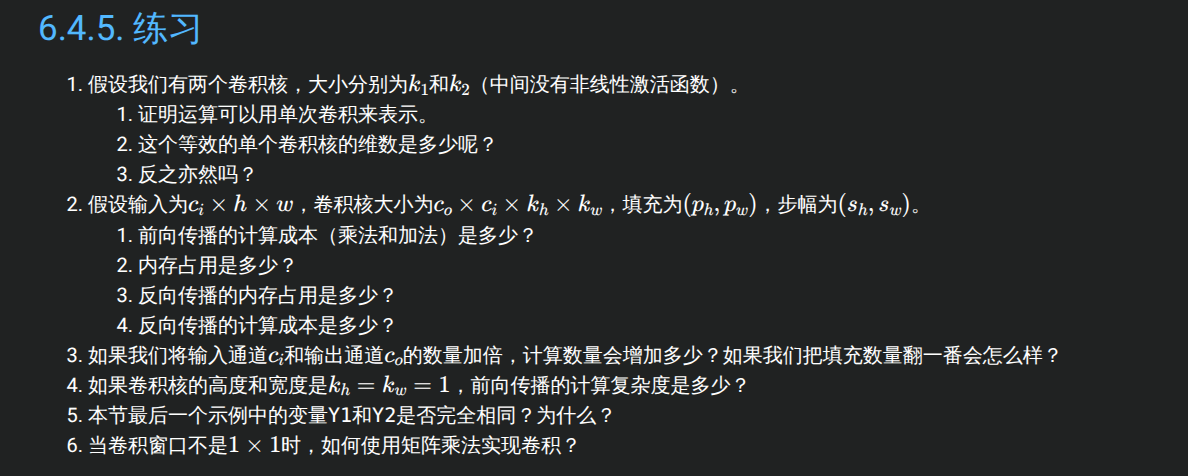
